In [4]:
from forestkernel import LeafEncoder
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from dataset import dataprep


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

## Read in the data and normalize

In [5]:
seed = 42
n_estimators = 500

forest = XGBClassifier(
    # device='cuda',  # only for GPU support
    # verbose=1,
    random_state=seed,
    n_estimators=n_estimators
)


# forest = GradientBoostingClassifier(
#     # verbose=1,
#     random_state=seed,
#     n_estimators=n_estimators
# )

# forest = LGBMClassifier(

#     random_state=seed,
#     n_estimators=n_estimators,
#     verbose=-1
# )

test_size=0.2

# data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_test.parquet')
# data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/tv_news_combined.parquet')
data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/iris.csv')

print(data.dtypes)


x, y   = dataprep(data, scale='normalize')

n_samples = x.shape[0]
n_features = x.shape[1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = test_size, random_state = seed)

print(f"Train samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Number of features: {x_train.shape[1]}")

species          object
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object
Initial shape: (150, 5)
Missing labels handling: drop_missing_y=False, kept 0 row(s) with missing values in 'species'.
Label column: 'species'
Label handling: factorized categorical/string labels into integer codes.
Number of classes: 3
Categorical feature columns: none
Continuous numeric feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Binary / indicator feature columns: none
Feature handling: no categorical feature columns to one-hot encode.
Scaling: normalized continuous numeric feature columns to [0, 1].
Final feature shape: (150, 4)
Train samples: 120, Test samples: 30
Number of features: 4


# Sanity check for boosted kernels

Leaf matrix shape: (120, 1500)
lr=0.001   nnz=0.717 Kmax=1.0000 Kmean=0.4202 wmin=0.00045 wmax=0.00107 slow_err=5.96e-08 slow_ok=True
Leaf matrix shape: (120, 1500)
lr=0.003   nnz=0.755 Kmax=1.0000 Kmean=0.4173 wmin=0.00034 wmax=0.00159 slow_err=1.79e-07 slow_ok=True
Leaf matrix shape: (120, 1500)
lr=0.01    nnz=0.781 Kmax=1.0000 Kmean=0.4161 wmin=0.00009 wmax=0.00306 slow_err=1.19e-07 slow_ok=True
Leaf matrix shape: (120, 1500)
lr=0.03    nnz=1.000 Kmax=1.0000 Kmean=0.4170 wmin=0.00000 wmax=0.00835 slow_err=1.19e-07 slow_ok=True
Leaf matrix shape: (120, 1500)
lr=0.1     nnz=1.000 Kmax=1.0000 Kmean=0.4193 wmin=0.00000 wmax=0.02670 slow_err=5.96e-08 slow_ok=True


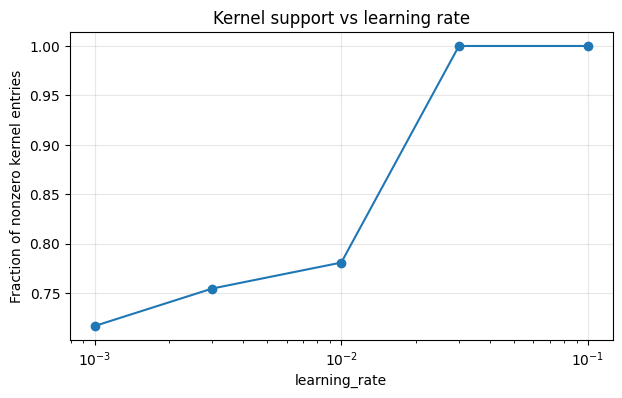

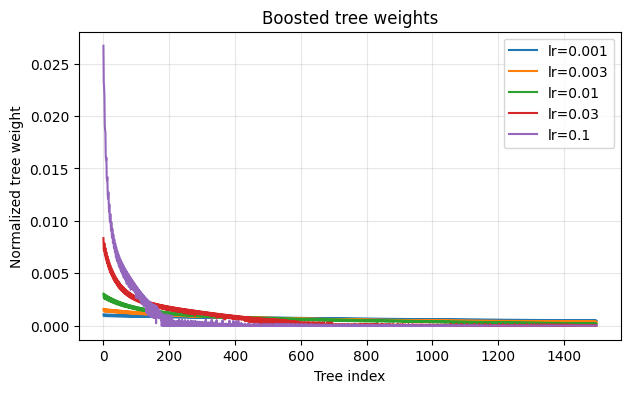

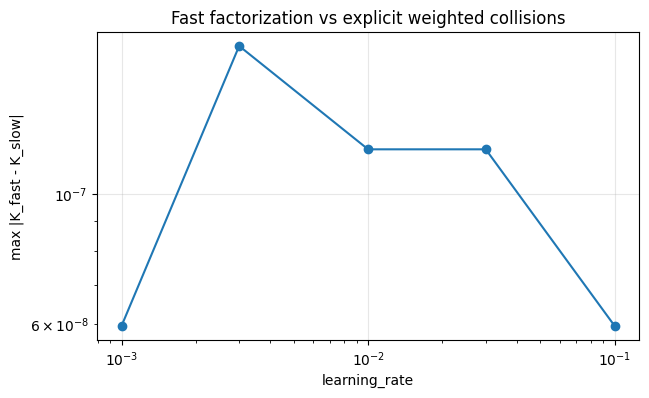

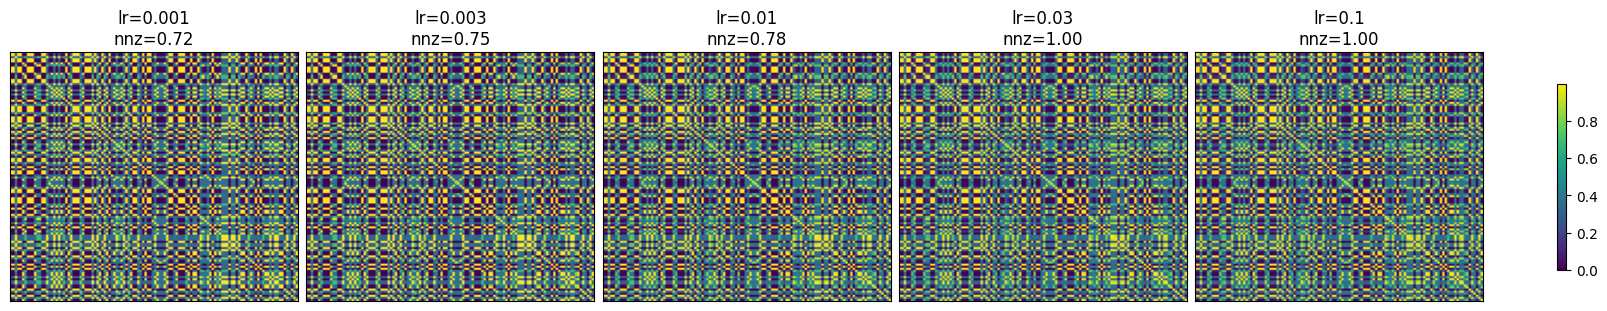

In [6]:
from sklearn.base import clone

learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]

encoders = {}
kernels = {}
supports = {}
weights = {}
slow_errors = {}

for lr in learning_rates:
    forest_lr = clone(forest).set_params(learning_rate=lr)

    gb_enc = LeafEncoder(
        forest=forest_lr,
        weight_scheme="boosted",
    ).fit(x_train, y_train)

    K = gb_enc.kernel(return_dense=True)
    w = gb_enc.forest_.get_tree_weights(x_train)

    leaves = gb_enc.forest_.get_leaf_matrix(x_train)
    print(f"Leaf matrix shape: {leaves.shape}")
    n, T = leaves.shape

    K_slow = np.zeros((n, n), dtype=np.float32)
    for t in range(T):
        same_leaf = leaves[:, [t]] == leaves[:, [t]].T
        K_slow += w[t] * same_leaf.astype(np.float32)

    slow_err = np.max(np.abs(K - K_slow))
    slow_ok = np.allclose(K, K_slow, rtol=1e-5, atol=1e-6)

    encoders[lr] = gb_enc
    kernels[lr] = K
    weights[lr] = w
    slow_errors[lr] = slow_err

    supports[lr] = {
        "nnz_frac": np.mean(K > 0),
        "above_1e-6_frac": np.mean(K > 1e-6),
        "above_1e-4_frac": np.mean(K > 1e-4),
        "min": K.min(),
        "max": K.max(),
        "mean": K.mean(),
        "slow_err": slow_err,
        "slow_ok": slow_ok,
    }

    print(
        f"lr={lr:<7} "
        f"nnz={supports[lr]['nnz_frac']:.3f} "
        f"Kmax={supports[lr]['max']:.4f} "
        f"Kmean={supports[lr]['mean']:.4f} "
        f"wmin={w.min():.5f} "
        f"wmax={w.max():.5f} "
        f"slow_err={slow_err:.2e} "
        f"slow_ok={slow_ok}"
    )


plt.figure(figsize=(7, 4))
plt.plot(
    learning_rates,
    [supports[lr]["nnz_frac"] for lr in learning_rates],
    marker="o",
)
plt.xscale("log")
plt.xlabel("learning_rate")
plt.ylabel("Fraction of nonzero kernel entries")
plt.title("Kernel support vs learning rate")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(7, 4))
for lr in learning_rates:
    plt.plot(weights[lr], label=f"lr={lr}")

plt.xlabel("Tree index")
plt.ylabel("Normalized tree weight")
plt.title("Boosted tree weights")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    learning_rates,
    [slow_errors[lr] for lr in learning_rates],
    marker="o",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("learning_rate")
plt.ylabel("max |K_fast - K_slow|")
plt.title("Fast factorization vs explicit weighted collisions")
plt.grid(alpha=0.3)
plt.show()


fig, axes = plt.subplots(
    1,
    len(learning_rates),
    figsize=(3.2 * len(learning_rates), 3),
    constrained_layout=True,
)

for ax, lr in zip(axes, learning_rates):
    im = ax.imshow(kernels[lr], aspect="auto")
    ax.set_title(f"lr={lr}\nnnz={supports[lr]['nnz_frac']:.2f}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.75)
plt.show()